In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

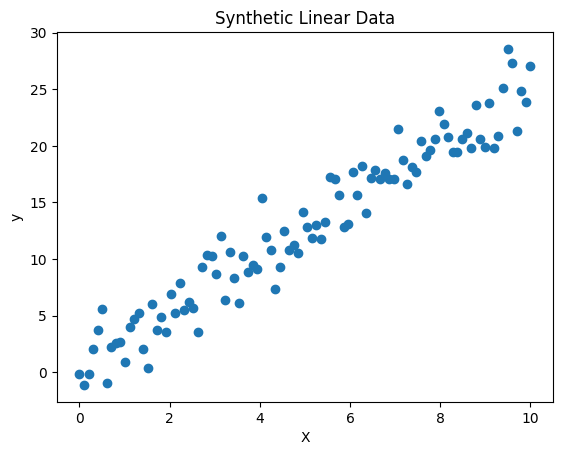

In [4]:
# lets prepare data for linear regression
x = np.linspace(0, 10, 100)
y = 2.5 * x + np.random.normal(0, 2, size=x.shape)
plt.scatter(x, y)
plt.title('Synthetic Linear Data')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

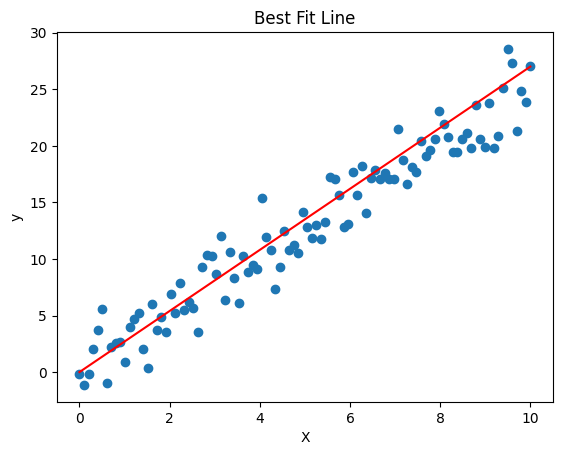

In [16]:
# lets try to fit best line here ( from scratch)
w1 = 2.7  # slope
w0 = 0  # intercept

y_pred = w1 * x + w0

plt.scatter(x, y)
plt.plot(x, y_pred, color='red')  # best fit line
plt.title('Best Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [17]:
# lets wrap data into pandas dataframe
df = pd.DataFrame({'X': x, 'y': y})
df.head()

,X,y
0,0.00000,-0.203321
1,0.10101,-1.134405
2,0.20202,-0.206819
3,0.30303,2.053180
4,0.40404,3.724335


In [20]:
# lets add Y_pred to dataframe
from os import error


df['y_pred'] = w1 * df['X'] + w0
df['error'] = df['y'] - df['y_pred']
errorsquared = df['error'] ** 2
mse = errorsquared.mean()
mse

np.float64(4.607572966449513)

In [21]:
# lets wrap in a function to test for different values of w1 and w0
def calculate_mse(w1, w0, df):
    df['y_pred'] = w1 * df['X'] + w0
    df['error'] = df['y'] - df['y_pred']
    errorsquared = df['error'] ** 2
    mse = errorsquared.mean()
    return mse


# lets try different values of w1 and w0
calculate_mse(2.5, 0, df)  # should be less than

np.float64(3.7507990453307696)

In [28]:
calculate_mse(2.46, 0.44, df)

np.float64(3.660493527556495)

In [ ]:
# conclusion:
# By adjusting the slope (w1) and intercept (w0) of the line, we can minimize the Mean Squared Error (MSE)
# between the predicted and actual values, thereby finding the best-fitting line for the given data.



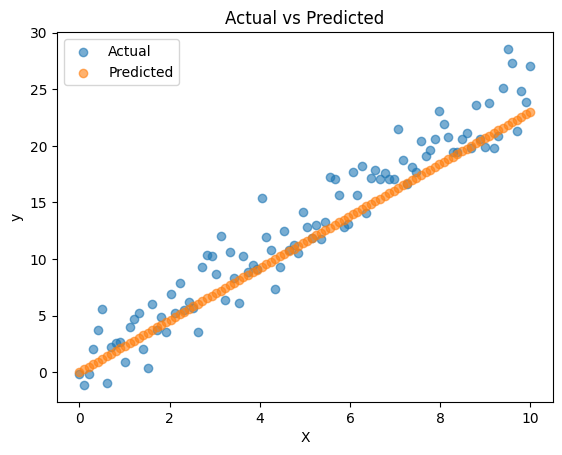

In [25]:
# lets plot actual vs predicted
plt.scatter(df['X'], df['y'], label='Actual', alpha=0.6)
plt.scatter(df['X'], df['y_pred'], label='Predicted', alpha=0.6)
plt.title('Actual vs Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

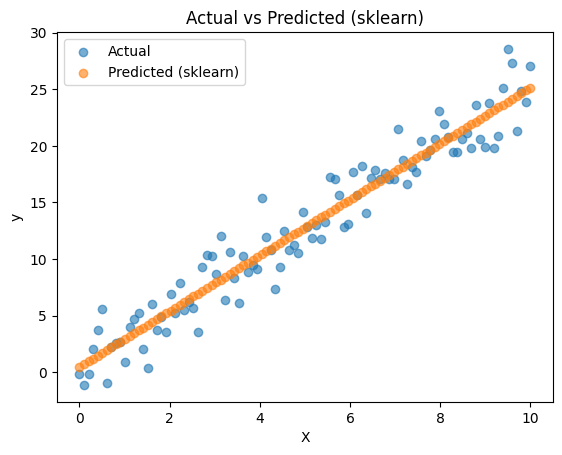

In [26]:
# you can direclty use linear regression from sklearn
from sklearn.linear_model import LinearRegression   
model = LinearRegression()
X = df[['X']]
y = df['y']
model.fit(X, y)
y_pred_sklearn = model.predict(X)
plt.scatter(df['X'], df['y'], label='Actual', alpha=0.6)
plt.scatter(df['X'], y_pred_sklearn, label='Predicted (sklearn)', alpha=0.6)
plt.title('Actual vs Predicted (sklearn)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [27]:
# here sklearn will find best w1 and w0 for us
w1_sklearn = model.coef_[0]
w0_sklearn = model.intercept_
w1_sklearn, w0_sklearn  

(np.float64(2.469579694247742), np.float64(0.44547300054161987))

In [30]:
# lets try different values of w1 and w0
w1 = [np.random.uniform(0, 5) for _ in range(100)]
w0 = [np.random.uniform(-5, 5) for _ in range(100)]
mse_values = []
for slope, intercept in zip(w1, w0):
    mse = calculate_mse(slope, intercept, df)
    print(f'For w1={slope:.2f}, w0={intercept:.2f} => MSE={mse:.2f}')
    mse_values.append(mse)


For w1=1.01, w0=-2.19 => MSE=120.25
For w1=1.06, w0=-1.31 => MSE=98.04
For w1=2.48, w0=-1.95 => MSE=9.20
For w1=2.36, w0=-1.31 => MSE=9.12
For w1=1.62, w0=-4.52 => MSE=94.98
For w1=3.04, w0=-4.65 => MSE=11.45
For w1=3.59, w0=-1.59 => MSE=26.80
For w1=0.50, w0=-3.60 => MSE=229.63
For w1=2.49, w0=-4.25 => MSE=24.56
For w1=0.19, w0=-3.92 => MSE=295.76
For w1=4.33, w0=2.41 => MSE=159.90
For w1=1.23, w0=-2.67 => MSE=103.29
For w1=3.95, w0=1.80 => MSE=99.31
For w1=3.88, w0=3.42 => MSE=121.11
For w1=4.23, w0=-0.19 => MSE=96.24
For w1=1.21, w0=3.62 => MSE=26.93
For w1=2.84, w0=4.51 => MSE=39.99
For w1=2.86, w0=-2.97 => MSE=7.08
For w1=3.40, w0=-0.99 => MSE=21.22
For w1=3.43, w0=-3.89 => MSE=11.79
For w1=4.50, w0=2.64 => MSE=191.12
For w1=1.77, w0=-4.49 => MSE=78.59
For w1=2.13, w0=1.08 => MSE=5.68
For w1=1.81, w0=2.30 => MSE=9.44
For w1=0.03, w0=3.47 => MSE=138.70
For w1=1.16, w0=-1.58 => MSE=91.69
For w1=4.14, w0=1.78 => MSE=120.97
For w1=2.36, w0=0.44 => MSE=4.07
For w1=2.51, w0=-1.16 => MSE

## Reference
- https://developers.google.com/machine-learning/crash-course/linear-regression/parameters-exercise